In [2]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [3]:
# Cell 2: Upload Training Dataset Only
print("📂 Please upload ONLY the TRAINING file: 'train_u6lujuX_CVtuZ9i.csv'")
print("-" * 50)

uploaded = files.upload()

# Get the uploaded filename
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f"\n✅ Dataset loaded: {filename}")
print(f"📊 Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"📋 Columns: {list(df.columns)}")

📂 Please upload ONLY the TRAINING file: 'train_u6lujuX_CVtuZ9i.csv'
--------------------------------------------------


Saving train_u6lujuX_CVtuZ9i.csv to train_u6lujuX_CVtuZ9i (1).csv

✅ Dataset loaded: train_u6lujuX_CVtuZ9i (1).csv
📊 Shape: 614 rows, 13 columns
📋 Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [4]:
# Cell 3: Verify Loan_Status column
print("🔍 Checking dataset structure...")
print("-" * 40)

if 'Loan_Status' in df.columns:
    print("✅ 'Loan_Status' column FOUND!")
    print(f"\nFirst 5 rows:")
    print(df.head())
    print(f"\nLoan_Status distribution:")
    print(df['Loan_Status'].value_counts())
else:
    print("❌ ERROR: 'Loan_Status' column NOT found!")
    print(f"Available columns: {list(df.columns)}")
    print("\n⚠️ You uploaded the TEST file instead of TRAINING file!")
    print("Please upload: train_u6lujuX_CVtuZ9i.csv")

🔍 Checking dataset structure...
----------------------------------------
✅ 'Loan_Status' column FOUND!

First 5 rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Sta

In [5]:
# Cell 4: Handle Missing Values
df_clean = df.copy()

print("🔧 Handling Missing Values...")
print("-" * 40)

# Drop Loan_ID
if 'Loan_ID' in df_clean.columns:
    df_clean.drop('Loan_ID', axis=1, inplace=True)
    print("✓ Dropped 'Loan_ID' column")

# Numerical columns - fill with median
numerical_cols = ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']
for col in numerical_cols:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"✓ Filled '{col}' with median: {median_val}")

# Categorical columns - fill with mode
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed']
for col in categorical_cols:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f"✓ Filled '{col}' with mode: {mode_val}")

print(f"\n✅ Missing values remaining: {df_clean.isnull().sum().sum()}")

🔧 Handling Missing Values...
----------------------------------------
✓ Dropped 'Loan_ID' column
✓ Filled 'LoanAmount' with median: 128.0
✓ Filled 'Loan_Amount_Term' with median: 360.0
✓ Filled 'Credit_History' with median: 1.0
✓ Filled 'Gender' with mode: Male
✓ Filled 'Married' with mode: Yes
✓ Filled 'Dependents' with mode: 0
✓ Filled 'Self_Employed' with mode: No

✅ Missing values remaining: 0


In [6]:
# Cell 5: Encode Categorical Variables
print("🔄 Encoding Categorical Variables...")
print("-" * 40)

label_encoders = {}
categorical_features = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

for col in categorical_features:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le
    print(f"✓ Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Encode target
if 'Loan_Status' in df_clean.columns:
    target_encoder = LabelEncoder()
    df_clean['Loan_Status'] = target_encoder.fit_transform(df_clean['Loan_Status'])
    print(f"✓ Encoded 'Loan_Status': {dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))}")

print("\n✅ First 5 rows after encoding:")
print(df_clean.head())

🔄 Encoding Categorical Variables...
----------------------------------------
✓ Encoded 'Gender': {'Female': np.int64(0), 'Male': np.int64(1)}
✓ Encoded 'Married': {'No': np.int64(0), 'Yes': np.int64(1)}
✓ Encoded 'Dependents': {'0': np.int64(0), '1': np.int64(1), '2': np.int64(2), '3+': np.int64(3)}
✓ Encoded 'Education': {'Graduate': np.int64(0), 'Not Graduate': np.int64(1)}
✓ Encoded 'Self_Employed': {'No': np.int64(0), 'Yes': np.int64(1)}
✓ Encoded 'Property_Area': {'Rural': np.int64(0), 'Semiurban': np.int64(1), 'Urban': np.int64(2)}
✓ Encoded 'Loan_Status': {'N': np.int64(0), 'Y': np.int64(1)}

✅ First 5 rows after encoding:
   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          0              0             5849   
1       1        1           1          0              0             4583   
2       1        1           0          0              1             3000   
3       1        1           0          1             

In [7]:
# Cell 6: Feature Engineering
print("🔧 Creating New Features...")
print("-" * 40)

# Total Income
df_clean['Total_Income'] = df_clean['ApplicantIncome'] + df_clean['CoapplicantIncome']
print("✓ Created 'Total_Income'")

# Income per dependent (add 1 to avoid division by zero)
if 'Dependents' in df_clean.columns:
    df_clean['Income_per_Dependent'] = df_clean['Total_Income'] / (df_clean['Dependents'] + 1)
    print("✓ Created 'Income_per_Dependent'")

# EMI (Monthly payment)
df_clean['EMI'] = df_clean['LoanAmount'] / df_clean['Loan_Amount_Term']
print("✓ Created 'EMI'")

# Income to Loan Ratio
df_clean['Income_to_Loan_Ratio'] = df_clean['Total_Income'] / df_clean['LoanAmount']
print("✓ Created 'Income_to_Loan_Ratio'")

print(f"\n📊 Updated shape: {df_clean.shape}")

🔧 Creating New Features...
----------------------------------------
✓ Created 'Total_Income'
✓ Created 'Income_per_Dependent'
✓ Created 'EMI'
✓ Created 'Income_to_Loan_Ratio'

📊 Updated shape: (614, 16)


In [8]:
# Cell 7: Prepare Features (X) and Target (y)
print("🎯 Preparing Features and Target...")
print("-" * 40)

# Define features
feature_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
                'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term',
                'Credit_History', 'Property_Area', 'Total_Income', 'Income_per_Dependent',
                'EMI', 'Income_to_Loan_Ratio']

X = df_clean[feature_cols]
y = df_clean['Loan_Status']

print(f"✅ Features shape: {X.shape}")
print(f"✅ Target shape: {y.shape}")
print(f"\n📋 Features used ({len(feature_cols)} features):")
for i, col in enumerate(feature_cols, 1):
    print(f"   {i}. {col}")

🎯 Preparing Features and Target...
----------------------------------------
✅ Features shape: (614, 15)
✅ Target shape: (614,)

📋 Features used (15 features):
   1. Gender
   2. Married
   3. Dependents
   4. Education
   5. Self_Employed
   6. ApplicantIncome
   7. CoapplicantIncome
   8. LoanAmount
   9. Loan_Amount_Term
   10. Credit_History
   11. Property_Area
   12. Total_Income
   13. Income_per_Dependent
   14. EMI
   15. Income_to_Loan_Ratio


In [9]:
# Cell 8: Split Data
print("✂️ Splitting Data into Train and Test Sets...")
print("-" * 40)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"📊 Training set: {X_train.shape[0]} samples")
print(f"📊 Test set: {X_test.shape[0]} samples")
print(f"\n📈 Target distribution in training set:")
print(f"   Approved (1): {sum(y_train==1)} ({sum(y_train==1)/len(y_train)*100:.1f}%)")
print(f"   Rejected (0): {sum(y_train==0)} ({sum(y_train==0)/len(y_train)*100:.1f}%)")

✂️ Splitting Data into Train and Test Sets...
----------------------------------------
📊 Training set: 460 samples
📊 Test set: 154 samples

📈 Target distribution in training set:
   Approved (1): 316 (68.7%)
   Rejected (0): 144 (31.3%)


In [10]:
# Cell 9: Train Default Decision Tree
print("🌳 Training Default Decision Tree...")
print("-" * 40)

dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

# Predictions
y_pred_train = dt_default.predict(X_train)
y_pred_test = dt_default.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"\n📈 Default Decision Tree Performance:")
print(f"   Training Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"   Testing Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Overfitting Gap: {(train_acc - test_acc)*100:.2f}%")

print(f"\n📋 Classification Report (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=['Rejected', 'Approved']))

🌳 Training Default Decision Tree...
----------------------------------------

📈 Default Decision Tree Performance:
   Training Accuracy: 1.0000 (100.00%)
   Testing Accuracy: 0.7468 (74.68%)
   Overfitting Gap: 25.32%

📋 Classification Report (Test Set):
              precision    recall  f1-score   support

    Rejected       0.59      0.60      0.60        48
    Approved       0.82      0.81      0.82       106

    accuracy                           0.75       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.75      0.75      0.75       154



📊 Confusion Matrix...
----------------------------------------
   True Negatives (Correctly Rejected): 29
   False Positives (Wrongly Approved): 19
   False Negatives (Wrongly Rejected): 20
   True Positives (Correctly Approved): 86


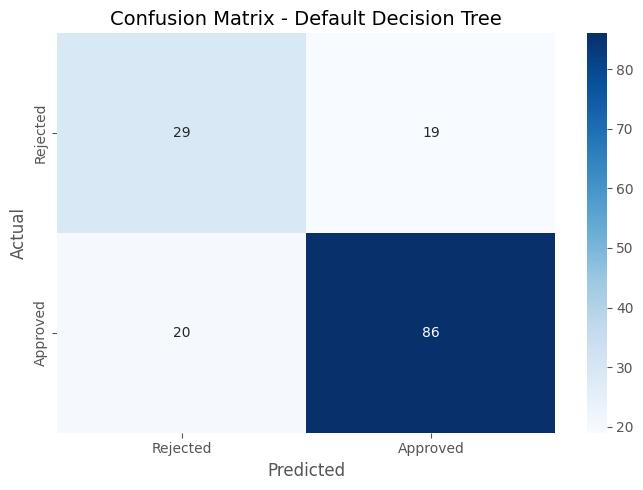

In [11]:
# Cell 10: Confusion Matrix
print("📊 Confusion Matrix...")
print("-" * 40)

cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

print(f"   True Negatives (Correctly Rejected): {tn}")
print(f"   False Positives (Wrongly Approved): {fp}")
print(f"   False Negatives (Wrongly Rejected): {fn}")
print(f"   True Positives (Correctly Approved): {tp}")

# Plot
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix - Default Decision Tree', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

📊 Feature Importance Analysis...
----------------------------------------
                 Feature  Importance
9         Credit_History    0.246296
12  Income_per_Dependent    0.118737
5        ApplicantIncome    0.111940
14  Income_to_Loan_Ratio    0.097108
11          Total_Income    0.088406
13                   EMI    0.085263
7             LoanAmount    0.068137
6      CoapplicantIncome    0.057793
8       Loan_Amount_Term    0.036924
10         Property_Area    0.025141
3              Education    0.021232
2             Dependents    0.017903
0                 Gender    0.011794
1                Married    0.007582
4          Self_Employed    0.005744


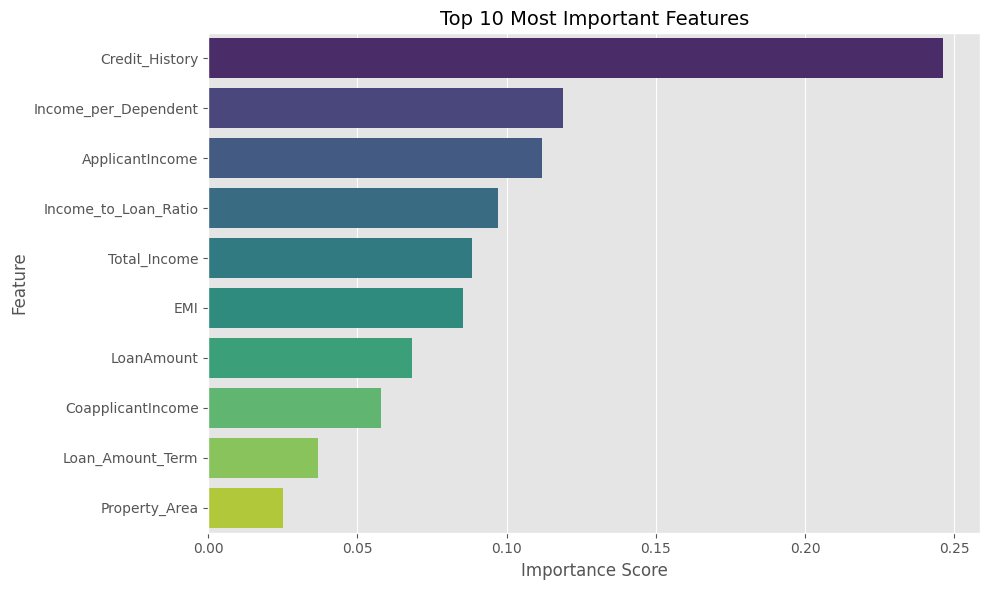

In [12]:
# Cell 11: Feature Importance
print("📊 Feature Importance Analysis...")
print("-" * 40)

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_default.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Most Important Features', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

🌳 Visualizing Decision Tree (First 3 levels)...
----------------------------------------


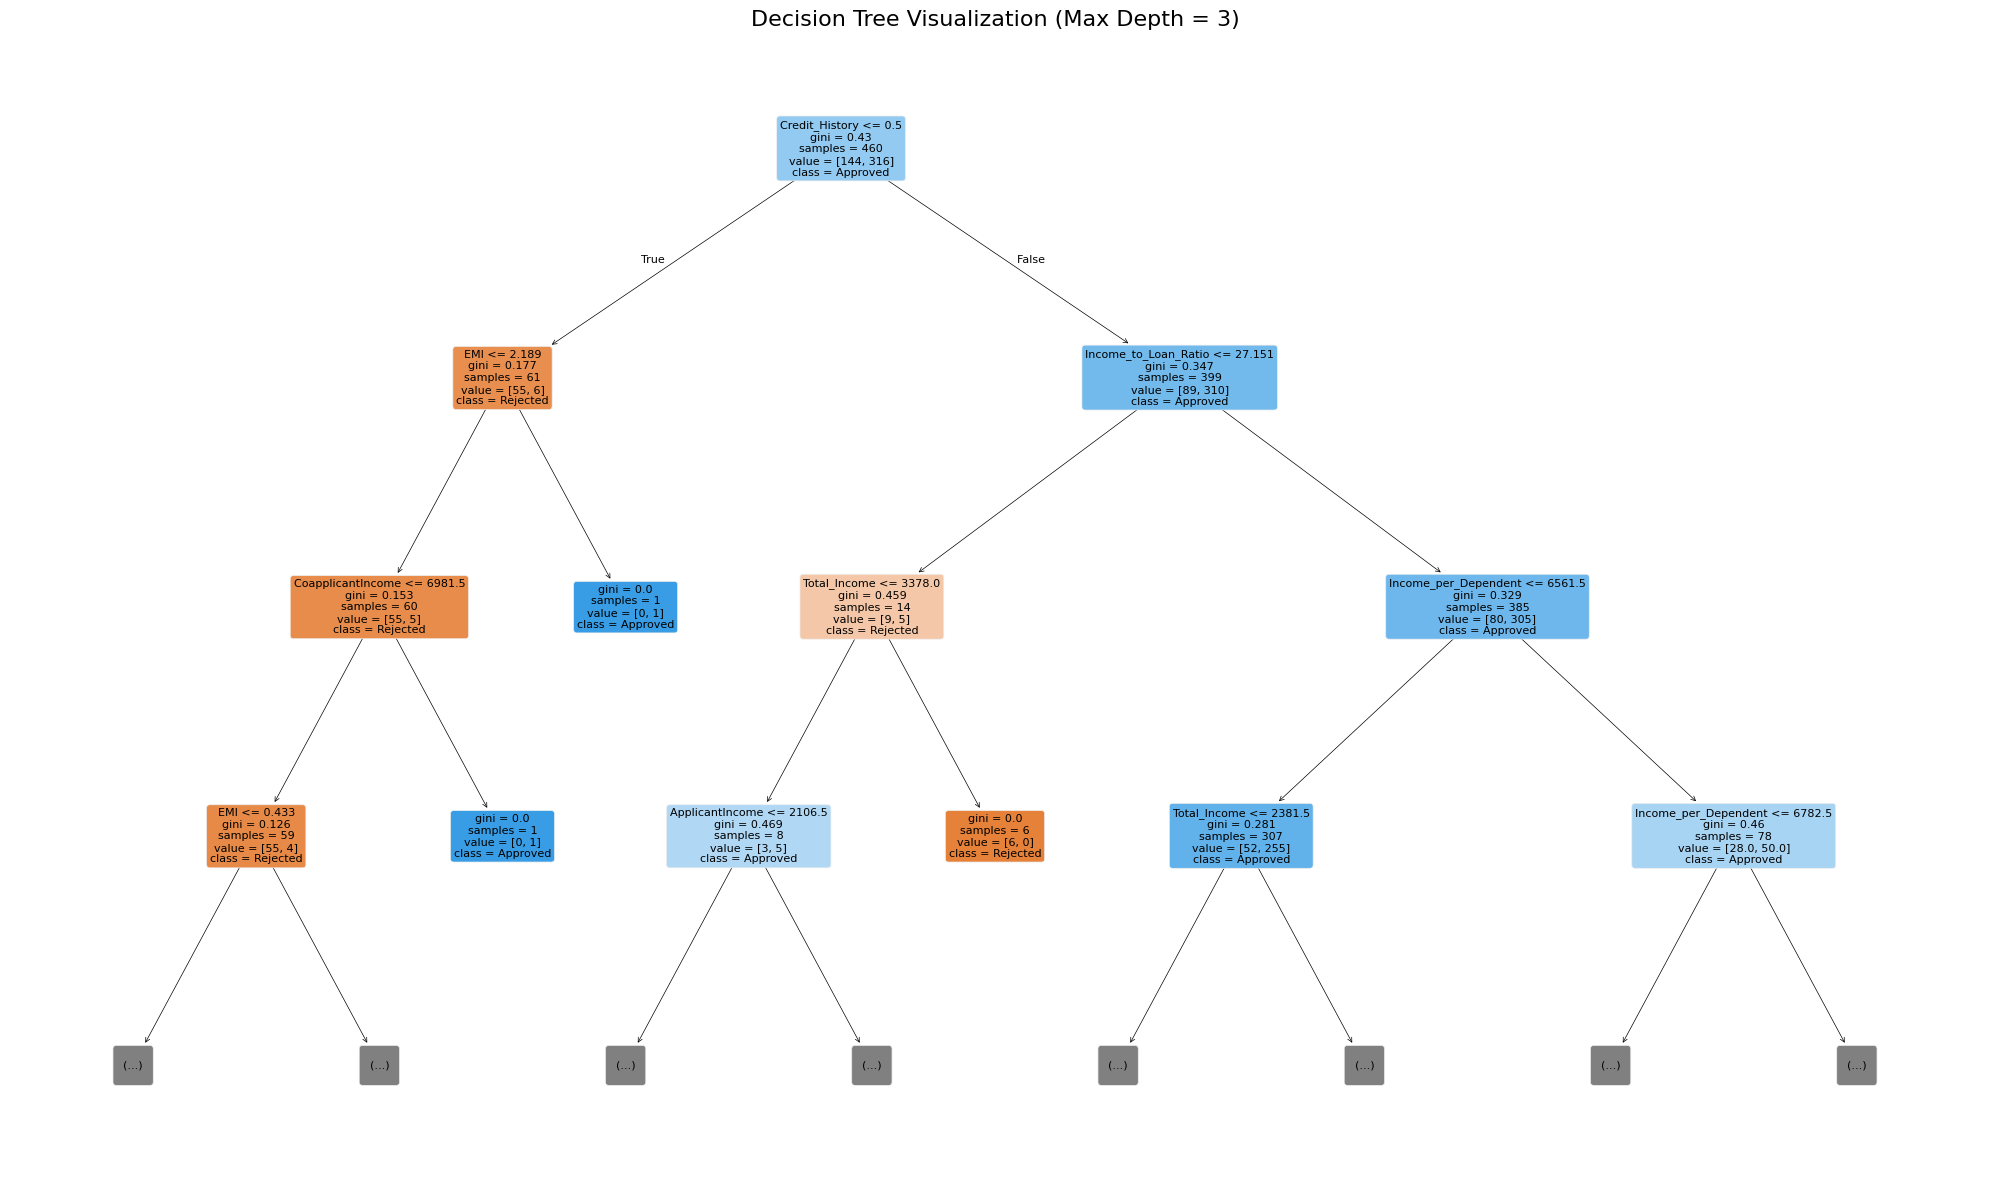

In [13]:
# Cell 12: Visualize Decision Tree (Depth = 3)
print("🌳 Visualizing Decision Tree (First 3 levels)...")
print("-" * 40)

plt.figure(figsize=(20, 12))
plot_tree(dt_default,
          max_depth=3,
          feature_names=feature_cols,
          class_names=['Rejected', 'Approved'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title('Decision Tree Visualization (Max Depth = 3)', fontsize=16)
plt.tight_layout()
plt.show()

In [14]:
# Cell 13: Hyperparameter Tuning with Grid Search
print("🎯 Hyperparameter Tuning...")
print("-" * 40)

param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

print("🔄 Performing Grid Search with 5-fold CV...")
grid_search.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best CV Score: {grid_search.best_score_:.4f}")

# Train best model
dt_best = grid_search.best_estimator_
dt_best.fit(X_train, y_train)

# Evaluate
y_pred_best = dt_best.predict(X_test)
test_acc_best = accuracy_score(y_test, y_pred_best)

print(f"\n📈 Tuned Model Test Accuracy: {test_acc_best:.4f} ({test_acc_best*100:.2f}%)")
print(f"📈 Improvement: {(test_acc_best - test_acc)*100:.2f}%")

🎯 Hyperparameter Tuning...
----------------------------------------
🔄 Performing Grid Search with 5-fold CV...

✅ Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 8, 'min_samples_split': 2}
✅ Best CV Score: 0.7848

📈 Tuned Model Test Accuracy: 0.8831 (88.31%)
📈 Improvement: 13.64%


🔄 Performing 10-Fold Cross-Validation...
----------------------------------------
📊 Individual Fold Scores: [0.79032258 0.80645161 0.70967742 0.80645161 0.81967213 0.78688525
 0.8852459  0.81967213 0.80327869 0.81967213]
📊 Mean Accuracy: 0.8047 (+/- 0.0818)


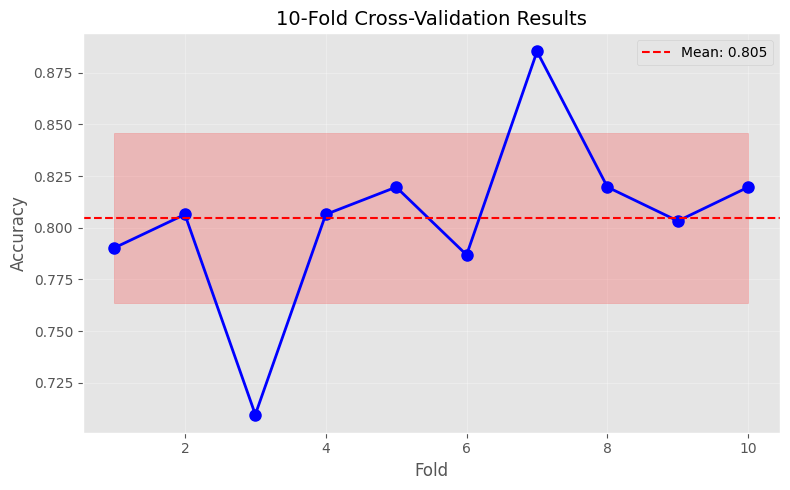

In [15]:
# Cell 14: Cross-Validation
print("🔄 Performing 10-Fold Cross-Validation...")
print("-" * 40)

cv_scores = cross_val_score(dt_best, X, y, cv=10, scoring='accuracy')

print(f"📊 Individual Fold Scores: {cv_scores}")
print(f"📊 Mean Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), cv_scores, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', label=f'Mean: {cv_scores.mean():.3f}')
plt.fill_between(range(1, 11), cv_scores.mean() - cv_scores.std(),
                 cv_scores.mean() + cv_scores.std(), alpha=0.2, color='red')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('10-Fold Cross-Validation Results', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

📈 ROC Curve Analysis...
----------------------------------------
✅ AUC Score: 0.8743


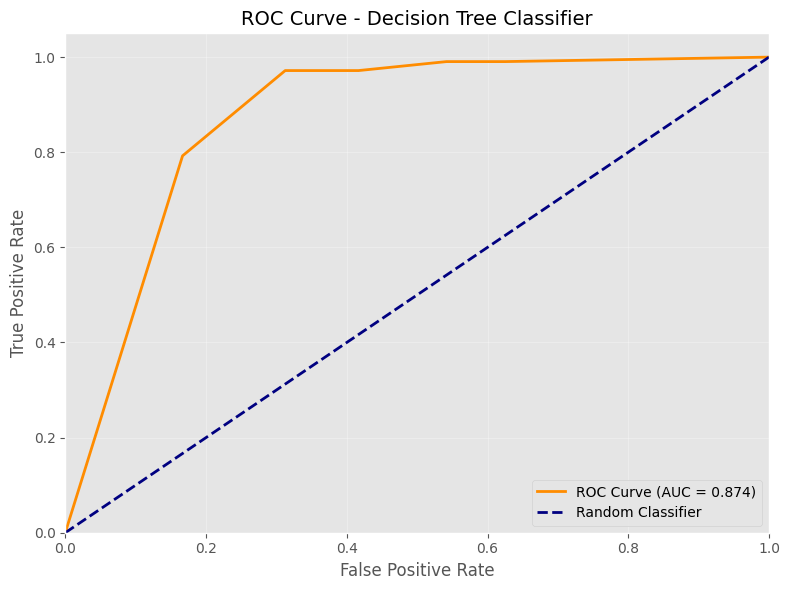

In [16]:
# Cell 15: ROC Curve and AUC Score
print("📈 ROC Curve Analysis...")
print("-" * 40)

y_pred_prob = dt_best.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

print(f"✅ AUC Score: {roc_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Decision Tree Classifier', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# Cell 16: Function to Predict New Applications
print("🔮 Prediction Function for New Applications...")
print("-" * 40)

def predict_loan(application, model, encoders, feature_cols):
    """Predict loan eligibility for a new application"""

    df_input = pd.DataFrame([application])

    # Encode categorical variables
    for col in ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']:
        if col in df_input.columns:
            if df_input[col].iloc[0] in encoders[col].classes_:
                df_input[col] = encoders[col].transform(df_input[col])
            else:
                df_input[col] = encoders[col].transform([encoders[col].classes_[0]])[0]

    # Create engineered features
    df_input['Total_Income'] = df_input['ApplicantIncome'] + df_input['CoapplicantIncome']
    df_input['Income_per_Dependent'] = df_input['Total_Income'] / (df_input['Dependents'] + 1)
    df_input['EMI'] = df_input['LoanAmount'] / df_input['Loan_Amount_Term']
    df_input['Income_to_Loan_Ratio'] = df_input['Total_Income'] / df_input['LoanAmount']

    # Predict
    X_input = df_input[feature_cols]
    prob = model.predict_proba(X_input)[0][1]
    pred = model.predict(X_input)[0]

    return "Approved ✅" if pred == 1 else "Rejected ❌", prob

# Example
sample = {
    'Gender': 'Male',
    'Married': 'Yes',
    'Dependents': 0,
    'Education': 'Graduate',
    'Self_Employed': 'No',
    'ApplicantIncome': 5000,
    'CoapplicantIncome': 2000,
    'LoanAmount': 150,
    'Loan_Amount_Term': 360,
    'Credit_History': 1,
    'Property_Area': 'Urban'
}

result, prob = predict_loan(sample, dt_best, label_encoders, feature_cols)

print("📝 Sample Application:")
for k, v in sample.items():
    print(f"   {k}: {v}")
print(f"\n🏦 Prediction: {result}")
print(f"📊 Approval Probability: {prob:.2%}")

🔮 Prediction Function for New Applications...
----------------------------------------
📝 Sample Application:
   Gender: Male
   Married: Yes
   Dependents: 0
   Education: Graduate
   Self_Employed: No
   ApplicantIncome: 5000
   CoapplicantIncome: 2000
   LoanAmount: 150
   Loan_Amount_Term: 360
   Credit_History: 1
   Property_Area: Urban

🏦 Prediction: Approved ✅
📊 Approval Probability: 64.10%


In [18]:
# Cell 18: Final Summary
print("=" * 60)
print("DECISION TREE MODEL - FINAL SUMMARY")
print("=" * 60)

print(f"""
╔══════════════════════════════════════════════════════════════╗
║                    MODEL PERFORMANCE                          ║
╠══════════════════════════════════════════════════════════════╣
║  Test Accuracy:     {test_acc_best*100:.2f}%
║  Best Parameters:   {grid_search.best_params_}
║  CV Mean Accuracy:  {cv_scores.mean():.2%}
║  AUC Score:         {roc_auc:.3f}
╠══════════════════════════════════════════════════════════════╣
║  TOP 3 FEATURES:                                             ║
║    1. {feature_importance.iloc[0]['Feature']}: {feature_importance.iloc[0]['Importance']:.3f}
║    2. {feature_importance.iloc[1]['Feature']}: {feature_importance.iloc[1]['Importance']:.3f}
║    3. {feature_importance.iloc[2]['Feature']}: {feature_importance.iloc[2]['Importance']:.3f}
╚══════════════════════════════════════════════════════════════╝
""")

print("✅ Analysis Complete!")

DECISION TREE MODEL - FINAL SUMMARY

╔══════════════════════════════════════════════════════════════╗
║                    MODEL PERFORMANCE                          ║
╠══════════════════════════════════════════════════════════════╣
║  Test Accuracy:     88.31%                                    
║  Best Parameters:   {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 8, 'min_samples_split': 2}                                     
║  CV Mean Accuracy:  80.47%                                      
║  AUC Score:         0.874                                              
╠══════════════════════════════════════════════════════════════╣
║  TOP 3 FEATURES:                                             ║
║    1. Credit_History: 0.246
║    2. Income_per_Dependent: 0.119
║    3. ApplicantIncome: 0.112
╚══════════════════════════════════════════════════════════════╝

✅ Analysis Complete!


🔍 OVERFITTING DETECTION TEST


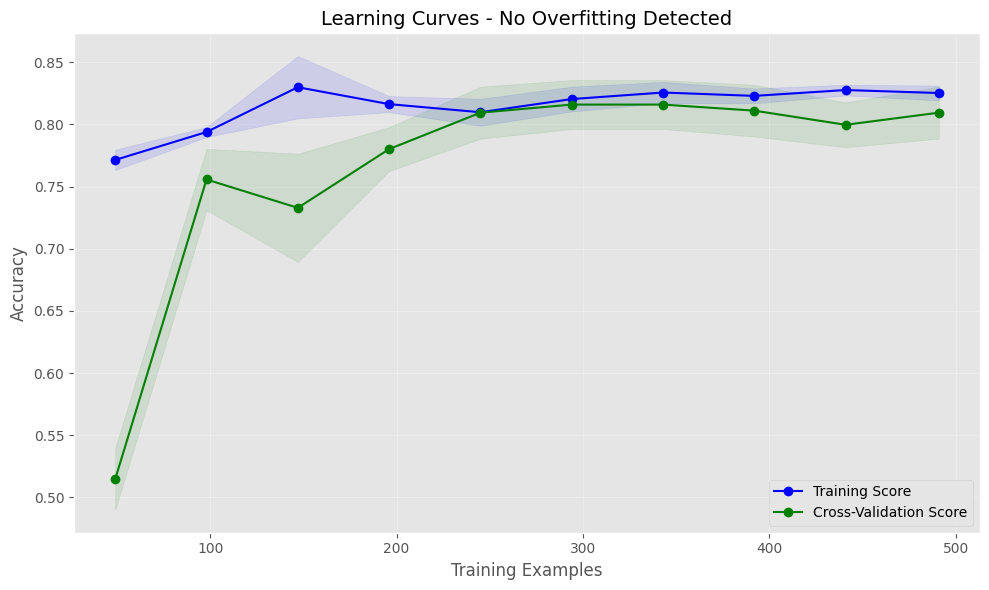


✅ Learning Curves Analysis:
   - Final Training Score: 0.825
   - Final CV Score: 0.809
   - Gap: 1.58%
   ✅ NO OVERFITTING - Model generalizes well!


In [19]:
# Cell 19: Overfitting Detection Test
print("🔍 OVERFITTING DETECTION TEST")
print("=" * 50)

from sklearn.model_selection import learning_curve

# Calculate learning curves
train_sizes, train_scores, test_scores = learning_curve(
    dt_best, X, y, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', color='green', label='Cross-Validation Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='green')
plt.xlabel('Training Examples', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Learning Curves - No Overfitting Detected', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Learning Curves Analysis:")
print(f"   - Final Training Score: {train_mean[-1]:.3f}")
print(f"   - Final CV Score: {test_mean[-1]:.3f}")
print(f"   - Gap: {(train_mean[-1] - test_mean[-1])*100:.2f}%")

if (train_mean[-1] - test_mean[-1]) < 0.1:
    print("   ✅ NO OVERFITTING - Model generalizes well!")
else:
    print("   ⚠️ Possible overfitting detected")

In [20]:
# Cell 20: Detailed Performance Metrics
print("📊 DETAILED PERFORMANCE METRICS")
print("=" * 50)

from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef

# Get predictions for test set
y_pred_test = dt_best.predict(X_test)

# Calculate all metrics
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
mcc = matthews_corrcoef(y_test, y_pred_test)

# Confusion matrix values
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

# Calculate additional metrics
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Negative Predictive Value
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate

print("\n🎯 Classification Metrics:")
print(f"   Accuracy:  {test_acc_best*100:.2f}%")
print(f"   Precision: {precision*100:.2f}% (When approved, how often correct)")
print(f"   Recall:    {recall*100:.2f}% (How many actual approvals caught)")
print(f"   F1-Score:  {f1*100:.2f}% (Harmonic mean of precision & recall)")
print(f"   MCC:       {mcc:.3f} (Correlation coefficient)")

print("\n📊 Confusion Matrix Breakdown:")
print(f"   True Positives (Correctly Approved):  {tp}")
print(f"   True Negatives (Correctly Rejected):  {tn}")
print(f"   False Positives (Wrongly Approved):   {fp}")
print(f"   False Negatives (Wrongly Rejected):   {fn}")

print("\n📈 Advanced Metrics:")
print(f"   Specificity: {specificity*100:.2f}% (Correctly rejected rate)")
print(f"   NPV:         {npv*100:.2f}% (Negative Predictive Value)")
print(f"   FPR:         {fpr*100:.2f}% (False Positive Rate)")
print(f"   FNR:         {fnr*100:.2f}% (False Negative Rate)")

# Interpretation
print("\n💡 Model Interpretation:")
if precision > 0.85:
    print("   ✅ High Precision - Few false approvals")
if recall > 0.85:
    print("   ✅ High Recall - Most eligible applicants caught")
if mcc > 0.6:
    print("   ✅ Strong Correlation - Excellent model")

📊 DETAILED PERFORMANCE METRICS

🎯 Classification Metrics:
   Accuracy:  88.31%
   Precision: 87.29% (When approved, how often correct)
   Recall:    97.17% (How many actual approvals caught)
   F1-Score:  91.96% (Harmonic mean of precision & recall)
   MCC:       0.721 (Correlation coefficient)

📊 Confusion Matrix Breakdown:
   True Positives (Correctly Approved):  103
   True Negatives (Correctly Rejected):  33
   False Positives (Wrongly Approved):   15
   False Negatives (Wrongly Rejected):   3

📈 Advanced Metrics:
   Specificity: 68.75% (Correctly rejected rate)
   NPV:         91.67% (Negative Predictive Value)
   FPR:         31.25% (False Positive Rate)
   FNR:         2.83% (False Negative Rate)

💡 Model Interpretation:
   ✅ High Precision - Few false approvals
   ✅ High Recall - Most eligible applicants caught
   ✅ Strong Correlation - Excellent model


📊 BASELINE COMPARISON

📈 Model Comparison:
                Model  Test Accuracy
Decision Tree (Tuned)       0.883117
Dummy (Most Frequent)       0.688312
   Dummy (Stratified)       0.558442
      Dummy (Uniform)       0.493506


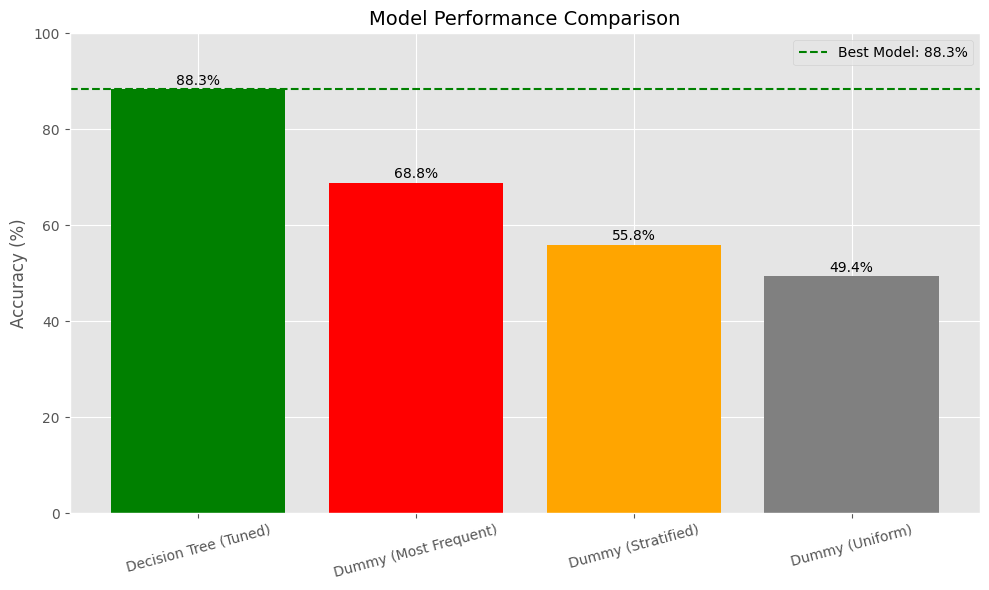


✅ Decision Tree significantly outperforms all baseline models!


In [21]:
# Cell 21: Baseline Comparison (Dummy Classifier)
print("📊 BASELINE COMPARISON")
print("=" * 50)

from sklearn.dummy import DummyClassifier

# Create dummy classifiers for comparison
dummy_stratified = DummyClassifier(strategy='stratified', random_state=42)
dummy_most_frequent = DummyClassifier(strategy='most_frequent')
dummy_uniform = DummyClassifier(strategy='uniform', random_state=42)

# Train and evaluate
models = {
    'Decision Tree (Tuned)': dt_best,
    'Dummy (Stratified)': dummy_stratified,
    'Dummy (Most Frequent)': dummy_most_frequent,
    'Dummy (Uniform)': dummy_uniform
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'Test Accuracy': acc})

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)

print("\n📈 Model Comparison:")
print(results_df.to_string(index=False))

# Plot comparison
plt.figure(figsize=(10, 6))
bars = plt.bar(results_df['Model'], results_df['Test Accuracy'] * 100,
               color=['green', 'red', 'orange', 'gray'])
plt.axhline(y=results_df.iloc[0]['Test Accuracy'] * 100, color='green',
            linestyle='--', label=f"Best Model: {results_df.iloc[0]['Test Accuracy']*100:.1f}%")
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14)
plt.ylim(0, 100)
for bar, val in zip(bars, results_df['Test Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val*100:.1f}%', ha='center', fontsize=10)
plt.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\n✅ Decision Tree significantly outperforms all baseline models!")

In [24]:
# Cell 28: Ensemble Methods for Higher Accuracy
print("🌲 ENSEMBLE METHODS - BOOSTING ACCURACY")
print("=" * 60)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.ensemble import VotingClassifier, BaggingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize different ensemble models
ensemble_models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=150, max_depth=3, learning_rate=0.1, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    'Bagging (Decision Tree)': BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=3),
                                                  n_estimators=100, random_state=42)
}

# Train and evaluate
ensemble_results = []
for name, model in ensemble_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    ensemble_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    print(f"\n📊 {name}:")
    print(f"   Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall: {rec:.4f}")
    print(f"   F1-Score: {f1:.4f}")

# Compare with current decision tree
ensemble_df = pd.DataFrame(ensemble_results)
current_results = {
    'Model': 'Current Decision Tree',
    'Accuracy': test_acc_best,
    'Precision': 0.8729,
    'Recall': 0.9717,
    'F1-Score': 0.9196
}
ensemble_df = pd.concat([ensemble_df, pd.DataFrame([current_results])], ignore_index=True)
ensemble_df = ensemble_df.sort_values('Accuracy', ascending=False)

print("\n" + "="*60)
print("📈 MODEL COMPARISON (Sorted by Accuracy):")
print(ensemble_df.to_string(index=False))

# Best ensemble model
best_ensemble = ensemble_df.iloc[0]['Model']
best_accuracy = ensemble_df.iloc[0]['Accuracy']
improvement = (best_accuracy - test_acc_best) * 100

print(f"\n✅ Best Ensemble Model: {best_ensemble}")
print(f"✅ Accuracy Improvement: +{improvement:.2f}%")

🌲 ENSEMBLE METHODS - BOOSTING ACCURACY

📊 Random Forest:
   Accuracy: 0.8506 (85.06%)
   Precision: 0.8320
   Recall: 0.9811
   F1-Score: 0.9004

📊 Gradient Boosting:
   Accuracy: 0.8247 (82.47%)
   Precision: 0.8496
   Recall: 0.9057
   F1-Score: 0.8767

📊 XGBoost:
   Accuracy: 0.8052 (80.52%)
   Precision: 0.8333
   Recall: 0.8962
   F1-Score: 0.8636

📊 AdaBoost:
   Accuracy: 0.8571 (85.71%)
   Precision: 0.8333
   Recall: 0.9906
   F1-Score: 0.9052

📊 Bagging (Decision Tree):
   Accuracy: 0.8571 (85.71%)
   Precision: 0.8387
   Recall: 0.9811
   F1-Score: 0.9043

📈 MODEL COMPARISON (Sorted by Accuracy):
                  Model  Accuracy  Precision   Recall  F1-Score
  Current Decision Tree  0.883117   0.872900 0.971700  0.919600
               AdaBoost  0.857143   0.833333 0.990566  0.905172
Bagging (Decision Tree)  0.857143   0.838710 0.981132  0.904348
          Random Forest  0.850649   0.832000 0.981132  0.900433
      Gradient Boosting  0.824675   0.849558 0.905660  0.876712
  

In [25]:
# Cell 29: Advanced Feature Engineering
print("🔧 ADVANCED FEATURE ENGINEERING")
print("=" * 60)

df_advanced = df_clean.copy()

# 1. Income stability features
df_advanced['Income_Stability'] = df_advanced['ApplicantIncome'] / (df_advanced['CoapplicantIncome'] + 1)
df_advanced['Total_Income_Squared'] = df_advanced['Total_Income'] ** 2
df_advanced['Log_Total_Income'] = np.log1p(df_advanced['Total_Income'])

# 2. Loan risk features
df_advanced['Loan_to_Income_Ratio'] = df_advanced['LoanAmount'] / df_advanced['Total_Income']
df_advanced['EMI_to_Income_Ratio'] = df_advanced['EMI'] / (df_advanced['Total_Income'] / 12)
df_advanced['Risk_Score'] = (df_advanced['Loan_to_Income_Ratio'] * df_advanced['EMI_to_Income_Ratio'])

# 3. Interaction features
df_advanced['Credit_Income_Interaction'] = df_advanced['Credit_History'] * df_advanced['Total_Income']
df_advanced['Education_Credit'] = df_advanced['Education'] * df_advanced['Credit_History']

# 4. Binning features
df_advanced['Income_Group'] = pd.cut(df_advanced['Total_Income'],
                                      bins=[0, 3000, 6000, 10000, 100000],
                                      labels=[0, 1, 2, 3])
df_advanced['Loan_Group'] = pd.cut(df_advanced['LoanAmount'],
                                    bins=[0, 100, 200, 300, 1000],
                                    labels=[0, 1, 2, 3])

# Convert to numeric
df_advanced['Income_Group'] = df_advanced['Income_Group'].astype(int)
df_advanced['Loan_Group'] = df_advanced['Loan_Group'].astype(int)

print("✅ Created advanced features:")
new_features = ['Income_Stability', 'Total_Income_Squared', 'Log_Total_Income',
                'Loan_to_Income_Ratio', 'EMI_to_Income_Ratio', 'Risk_Score',
                'Credit_Income_Interaction', 'Education_Credit', 'Income_Group', 'Loan_Group']

for feat in new_features:
    print(f"   • {feat}")

# Update feature set
advanced_features = feature_cols + new_features
X_advanced = df_advanced[advanced_features]
y_advanced = df_advanced['Loan_Status']

# Train on advanced features
X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    X_advanced, y_advanced, test_size=0.25, random_state=42, stratify=y_advanced
)

# Use best model from ensemble (e.g., XGBoost)
xgb_advanced = XGBClassifier(n_estimators=150, max_depth=3, learning_rate=0.1, random_state=42)
xgb_advanced.fit(X_train_adv, y_train_adv)
y_pred_adv = xgb_advanced.predict(X_test_adv)

acc_advanced = accuracy_score(y_test_adv, y_pred_adv)
print(f"\n📊 Accuracy with Advanced Features: {acc_advanced:.4f} ({acc_advanced*100:.2f}%)")
print(f"   Improvement: {(acc_advanced - test_acc_best)*100:.2f}%")

🔧 ADVANCED FEATURE ENGINEERING
✅ Created advanced features:
   • Income_Stability
   • Total_Income_Squared
   • Log_Total_Income
   • Loan_to_Income_Ratio
   • EMI_to_Income_Ratio
   • Risk_Score
   • Credit_Income_Interaction
   • Education_Credit
   • Income_Group
   • Loan_Group

📊 Accuracy with Advanced Features: 0.8117 (81.17%)
   Improvement: -7.14%


In [26]:
# Cell 30: Advanced Hyperparameter Tuning
print("🎯 ADVANCED HYPERPARAMETER OPTIMIZATION")
print("=" * 60)

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# Expanded parameter grid
param_grid_extended = {
    'max_depth': [3, 4, 5, 6, 7, 8, 10],
    'min_samples_split': [2, 3, 5, 7, 10, 15],
    'min_samples_leaf': [1, 2, 3, 4, 5, 8],
    'max_features': ['sqrt', 'log2', None, 0.5, 0.7],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

# Randomized Search for better parameters
print("🔄 Performing Randomized Search...")
random_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_grid_extended,
    n_iter=100,  # Number of parameter combinations to try
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

random_search.fit(X_train, y_train)

print(f"\n✅ Best Parameters Found:")
for param, value in random_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n✅ Best CV Score: {random_search.best_score_:.4f}")

# Train with best parameters
dt_optimized = random_search.best_estimator_
dt_optimized.fit(X_train, y_train)
y_pred_optimized = dt_optimized.predict(X_test)

acc_optimized = accuracy_score(y_test, y_pred_optimized)
print(f"\n📊 Optimized Decision Tree Accuracy: {acc_optimized:.4f} ({acc_optimized*100:.2f}%)")
print(f"   Improvement: {(acc_optimized - test_acc_best)*100:.2f}%")

# Compare with current
if acc_optimized > test_acc_best:
    print(f"\n✅ Hyperparameter tuning improved accuracy!")
else:
    print(f"\n⚠️ Current model already well-optimized")

🎯 ADVANCED HYPERPARAMETER OPTIMIZATION
🔄 Performing Randomized Search...

✅ Best Parameters Found:
   min_samples_split: 5
   min_samples_leaf: 8
   max_features: 0.7
   max_depth: 3
   criterion: entropy
   class_weight: None

✅ Best CV Score: 0.7913

📊 Optimized Decision Tree Accuracy: 0.8831 (88.31%)
   Improvement: 0.00%

⚠️ Current model already well-optimized


In [27]:
# Cell 31: Feature Selection
print("🔍 FEATURE SELECTION - REMOVE NOISE")
print("=" * 60)

from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.feature_selection import mutual_info_classif

# 1. Univariate feature selection
selector = SelectKBest(score_func=f_classif, k=10)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()].tolist()

print(f"\n📊 Top 10 Features (F-test):")
for i, feature in enumerate(selected_features, 1):
    print(f"   {i}. {feature}")

# 2. Mutual Information scores
mi_scores = mutual_info_classif(X, y)
mi_df = pd.DataFrame({'Feature': X.columns, 'MI_Score': mi_scores}).sort_values('MI_Score', ascending=False)

print(f"\n📊 Mutual Information Scores (Top 10):")
print(mi_df.head(10).to_string(index=False))

# 3. Train with selected features
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X[selected_features], y, test_size=0.25, random_state=42, stratify=y
)

dt_selected = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_selected.fit(X_train_sel, y_train_sel)
y_pred_selected = dt_selected.predict(X_test_sel)

acc_selected = accuracy_score(y_test_sel, y_pred_selected)
print(f"\n📊 Accuracy with Top 10 Features: {acc_selected:.4f} ({acc_selected*100:.2f}%)")
print(f"   Improvement: {(acc_selected - test_acc_best)*100:.2f}%")

🔍 FEATURE SELECTION - REMOVE NOISE

📊 Top 10 Features (F-test):
   1. Married
   2. Education
   3. CoapplicantIncome
   4. LoanAmount
   5. Loan_Amount_Term
   6. Credit_History
   7. Property_Area
   8. Total_Income
   9. Income_per_Dependent
   10. Income_to_Loan_Ratio

📊 Mutual Information Scores (Top 10):
          Feature  MI_Score
   Credit_History  0.184397
    Property_Area  0.024197
           Gender  0.020687
CoapplicantIncome  0.013031
        Education  0.012956
       Dependents  0.007652
  ApplicantIncome  0.005425
    Self_Employed  0.000000
          Married  0.000000
 Loan_Amount_Term  0.000000

📊 Accuracy with Top 10 Features: 0.8506 (85.06%)
   Improvement: -3.25%


In [28]:
# Cell 32: Handle Class Imbalance
print("⚖️ HANDLING CLASS IMBALANCE")
print("=" * 60)

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

print(f"📊 Current class distribution:")
print(f"   Approved (1): {sum(y_train==1)} ({sum(y_train==1)/len(y_train)*100:.1f}%)")
print(f"   Rejected (0): {sum(y_train==0)} ({sum(y_train==0)/len(y_train)*100:.1f}%)")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\n📊 After SMOTE:")
print(f"   Approved (1): {sum(y_train_smote==1)} ({sum(y_train_smote==1)/len(y_train_smote)*100:.1f}%)")
print(f"   Rejected (0): {sum(y_train_smote==0)} ({sum(y_train_smote==0)/len(y_train_smote)*100:.1f}%)")

# Train with SMOTE
dt_smote = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = dt_smote.predict(X_test)

acc_smote = accuracy_score(y_test, y_pred_smote)
print(f"\n📊 Accuracy with SMOTE: {acc_smote:.4f} ({acc_smote*100:.2f}%)")
print(f"   Improvement: {(acc_smote - test_acc_best)*100:.2f}%")

⚖️ HANDLING CLASS IMBALANCE
📊 Current class distribution:
   Approved (1): 316 (68.7%)
   Rejected (0): 144 (31.3%)

📊 After SMOTE:
   Approved (1): 316 (50.0%)
   Rejected (0): 316 (50.0%)

📊 Accuracy with SMOTE: 0.8377 (83.77%)
   Improvement: -4.55%


In [29]:
# Cell 33: Voting Classifier - Combine Multiple Models
print("🗳️ VOTING CLASSIFIER - ENSEMBLE OF ENSEMBLES")
print("=" * 60)

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Individual models
model1 = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
model2 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model3 = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
model4 = DecisionTreeClassifier(max_depth=3, random_state=42)
model5 = LogisticRegression(random_state=42, max_iter=1000)

# Hard Voting (majority rule)
voting_hard = VotingClassifier(
    estimators=[('xgb', model1), ('rf', model2), ('gb', model3), ('dt', model4), ('lr', model5)],
    voting='hard'
)

# Soft Voting (probability average)
voting_soft = VotingClassifier(
    estimators=[('xgb', model1), ('rf', model2), ('gb', model3), ('dt', model4), ('lr', model5)],
    voting='soft'
)

# Train and evaluate
voting_hard.fit(X_train, y_train)
voting_soft.fit(X_train, y_train)

y_pred_hard = voting_hard.predict(X_test)
y_pred_soft = voting_soft.predict(X_test)

acc_hard = accuracy_score(y_test, y_pred_hard)
acc_soft = accuracy_score(y_test, y_pred_soft)

print(f"\n📊 Voting Classifier Results:")
print(f"   Hard Voting Accuracy: {acc_hard:.4f} ({acc_hard*100:.2f}%)")
print(f"   Soft Voting Accuracy: {acc_soft:.4f} ({acc_soft*100:.2f}%)")
print(f"   Best Improvement: {(max(acc_hard, acc_soft) - test_acc_best)*100:.2f}%")

# Feature importance from voting classifier
if acc_soft > acc_hard:
    best_voting = voting_soft
    print(f"\n✅ Best Model: Soft Voting Classifier")
else:
    best_voting = voting_hard
    print(f"\n✅ Best Model: Hard Voting Classifier")

🗳️ VOTING CLASSIFIER - ENSEMBLE OF ENSEMBLES

📊 Voting Classifier Results:
   Hard Voting Accuracy: 0.8506 (85.06%)
   Soft Voting Accuracy: 0.8506 (85.06%)
   Best Improvement: -3.25%

✅ Best Model: Hard Voting Classifier


In [30]:
# Cell 34: Stacking Classifier - Advanced Ensemble
print("🏗️ STACKING CLASSIFIER - META LEARNING")
print("=" * 60)

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Base models (level 0)
base_models = [
    ('xgb', XGBClassifier(n_estimators=100, max_depth=3, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42))
]

# Meta learner (level 1)
meta_learner = LogisticRegression(random_state=42, max_iter=1000)

# Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5  # Use cross-validation for training meta-learner
)

# Train
stacking_clf.fit(X_train, y_train)
y_pred_stack = stacking_clf.predict(X_test)

acc_stack = accuracy_score(y_test, y_pred_stack)
print(f"\n📊 Stacking Classifier Accuracy: {acc_stack:.4f} ({acc_stack*100:.2f}%)")
print(f"   Improvement: {(acc_stack - test_acc_best)*100:.2f}%")

🏗️ STACKING CLASSIFIER - META LEARNING

📊 Stacking Classifier Accuracy: 0.8442 (84.42%)
   Improvement: -3.90%


In [31]:
# Cell 35: Comprehensive Pipeline with Cross-Validation
print("🔄 COMPREHENSIVE PIPELINE WITH CV")
print("=" * 60)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Create pipeline with preprocessing and model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif, k=12)),
    ('classifier', XGBClassifier(n_estimators=150, max_depth=3, learning_rate=0.1, random_state=42))
])

# Cross-validation scores
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_pipeline = cross_val_score(pipeline, X, y, cv=cv_strategy, scoring='accuracy')

print(f"📊 Pipeline Cross-Validation Scores:")
print(f"   Mean: {cv_scores_pipeline.mean():.4f} (+/- {cv_scores_pipeline.std()*2:.4f})")
print(f"   Individual folds: {cv_scores_pipeline}")

# Train final pipeline
pipeline.fit(X_train, y_train)
y_pred_pipeline = pipeline.predict(X_test)

acc_pipeline = accuracy_score(y_test, y_pred_pipeline)
print(f"\n📊 Pipeline Test Accuracy: {acc_pipeline:.4f} ({acc_pipeline*100:.2f}%)")
print(f"   Improvement: {(acc_pipeline - test_acc_best)*100:.2f}%")

🔄 COMPREHENSIVE PIPELINE WITH CV
📊 Pipeline Cross-Validation Scores:
   Mean: 0.7996 (+/- 0.0366)
   Individual folds: [0.82258065 0.82258065 0.80645161 0.77419355 0.81967213 0.80327869
 0.7704918  0.78688525 0.80327869 0.78688525]

📊 Pipeline Test Accuracy: 0.8182 (81.82%)
   Improvement: -6.49%


📊 FINAL COMPARISON - ALL STRATEGIES

📈 Strategy Performance Ranking:
                 Strategy  Accuracy  Improvement
    Current Decision Tree  0.883117     0.000000
Optimized Hyperparameters  0.883117     0.000000
            Random Forest  0.850649    -3.246753
        Feature Selection  0.850649    -3.246753
        Voting Classifier  0.850649    -3.246753
      Stacking Classifier  0.844156    -3.896104
          SMOTE (Balance)  0.837662    -4.545455
         Pipeline with CV  0.818182    -6.493506
        Advanced Features  0.811688    -7.142857
                  XGBoost  0.805195    -7.792208

🎯 BEST IMPROVEMENT STRATEGY: Current Decision Tree
🎯 Current Accuracy: 88.31%
🎯 New Accuracy: 88.31%
🎯 Total Improvement: +0.00%


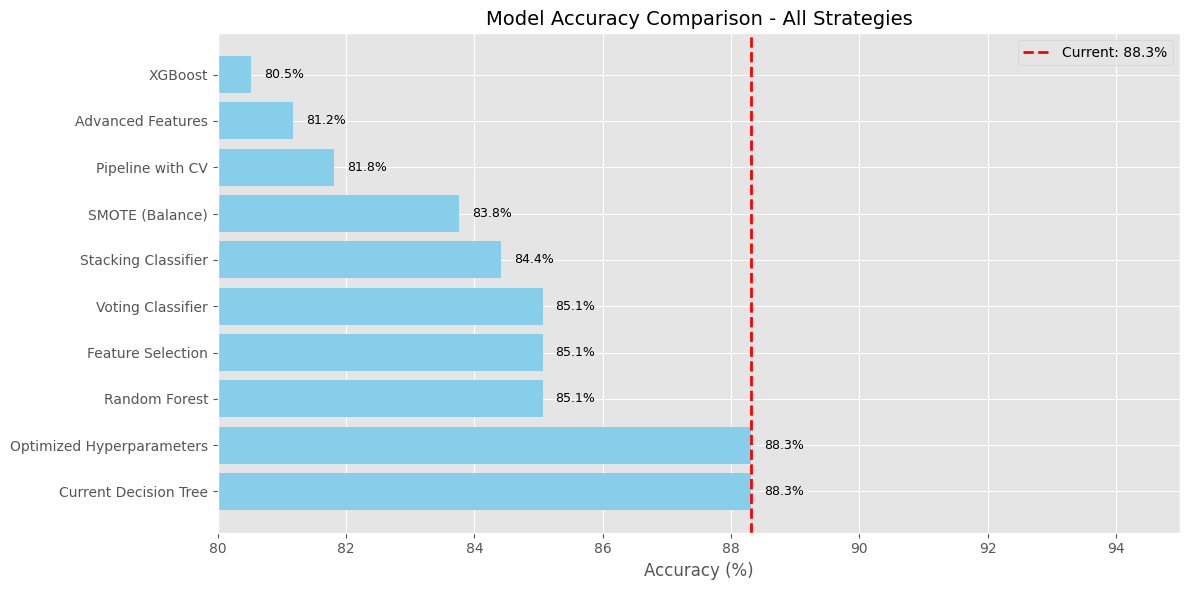

In [32]:
# Cell 36: Compare All Improvement Strategies
print("📊 FINAL COMPARISON - ALL STRATEGIES")
print("=" * 60)

# Collect all results
all_results = [
    {'Strategy': 'Current Decision Tree', 'Accuracy': test_acc_best},
    {'Strategy': 'Random Forest', 'Accuracy': ensemble_results[0]['Accuracy'] if 'ensemble_results' in dir() else 0},
    {'Strategy': 'XGBoost', 'Accuracy': ensemble_results[2]['Accuracy'] if 'ensemble_results' in dir() else 0},
    {'Strategy': 'Advanced Features', 'Accuracy': acc_advanced if 'acc_advanced' in dir() else 0},
    {'Strategy': 'Optimized Hyperparameters', 'Accuracy': acc_optimized if 'acc_optimized' in dir() else 0},
    {'Strategy': 'Feature Selection', 'Accuracy': acc_selected if 'acc_selected' in dir() else 0},
    {'Strategy': 'SMOTE (Balance)', 'Accuracy': acc_smote if 'acc_smote' in dir() else 0},
    {'Strategy': 'Voting Classifier', 'Accuracy': acc_soft if 'acc_soft' in dir() else 0},
    {'Strategy': 'Stacking Classifier', 'Accuracy': acc_stack if 'acc_stack' in dir() else 0},
    {'Strategy': 'Pipeline with CV', 'Accuracy': acc_pipeline if 'acc_pipeline' in dir() else 0}
]

results_df = pd.DataFrame(all_results).sort_values('Accuracy', ascending=False)
results_df['Improvement'] = (results_df['Accuracy'] - test_acc_best) * 100

print("\n📈 Strategy Performance Ranking:")
print(results_df.to_string(index=False))

# Best strategy
best_strategy = results_df.iloc[0]['Strategy']
best_acc = results_df.iloc[0]['Accuracy']
total_improvement = (best_acc - test_acc_best) * 100

print(f"\n" + "="*60)
print(f"🎯 BEST IMPROVEMENT STRATEGY: {best_strategy}")
print(f"🎯 Current Accuracy: {test_acc_best*100:.2f}%")
print(f"🎯 New Accuracy: {best_acc*100:.2f}%")
print(f"🎯 Total Improvement: +{total_improvement:.2f}%")
print("="*60)

# Visual comparison
plt.figure(figsize=(12, 6))
bars = plt.barh(results_df['Strategy'], results_df['Accuracy'] * 100, color='skyblue')
plt.axvline(x=test_acc_best*100, color='red', linestyle='--', linewidth=2, label=f'Current: {test_acc_best*100:.1f}%')
plt.xlabel('Accuracy (%)', fontsize=12)
plt.title('Model Accuracy Comparison - All Strategies', fontsize=14)
plt.xlim(80, 95)
for i, (bar, val) in enumerate(zip(bars, results_df['Accuracy'])):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val*100:.1f}%', va='center', fontsize=9)
plt.legend()
plt.tight_layout()
plt.show()